# 1. Environment Setup & Libraries

In [23]:
# Install seaborn
%pip install seaborn

# Import standard data manipulation and visualization libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Import machine learning models and preprocessing tools
import xgboost as xgb
from sklearn.svm import SVR
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from pandas.api.types import CategoricalDtype
from pandas.tseries.holiday import USFederalHolidayCalendar

# Set global plot styling
sns.set_theme(style="whitegrid")

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.3.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


# 2. Exploratory Data Analysis (EDA)

### 2.1 Load Raw ABT & Inspect Target Distribution (`net_revenue_per_hour`)

Net Revenue per Hour Quantiles:
0.010     $28.56
0.050     $54.96
0.250     $71.61
0.500     $85.41
0.750    $105.17
0.900    $133.77
0.950    $158.31
0.990    $223.78
0.999    $223.78
Name: net_revenue_per_hour, dtype: str

99th percentile cap for readable plotting: $223.78


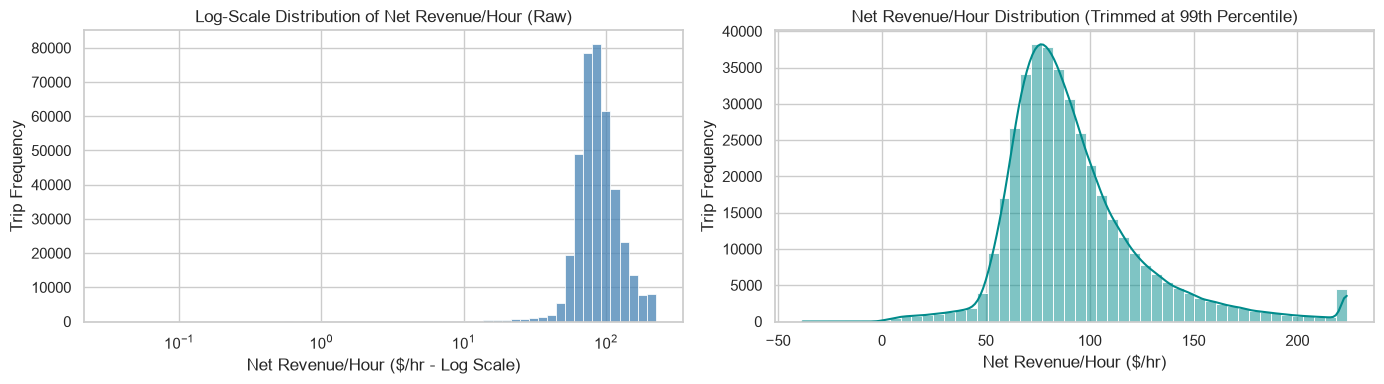

In [24]:
# Load the initial Analytical Base Table (ABT)
df = pd.read_csv('../data/NYC_Taxi_ABT.csv')

# Sample 10% of the dataset for fast, responsive visualization
eda_df = df.sample(frac=0.10, random_state=42).copy()

# Inspect distribution quantiles for net_revenue_per_hour
quantiles = [0.01, 0.05, 0.25, 0.50, 0.75, 0.90, 0.95, 0.99, 0.999]
print("Net Revenue per Hour Quantiles:")
print(eda_df['net_revenue_per_hour'].quantile(quantiles).apply(lambda x: f"${x:,.2f}"))

# Identify 99th percentile threshold to cap extreme trip outliers for readable plotting
cap_value = eda_df['net_revenue_per_hour'].quantile(0.99)
print(f"\n99th percentile cap for readable plotting: ${cap_value:.2f}")

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Plot 1: Raw distribution (Log Scale)
sns.histplot(eda_df['net_revenue_per_hour'], bins=60, log_scale=True, ax=axes[0], color='steelblue')
axes[0].set_title('Log-Scale Distribution of Net Revenue/Hour (Raw)')
axes[0].set_xlabel('Net Revenue/Hour ($/hr - Log Scale)')
axes[0].set_ylabel('Trip Frequency')

# Plot 2: Filtered distribution (Trimmed at 99th Percentile)
sns.histplot(eda_df[eda_df['net_revenue_per_hour'] <= cap_value]['net_revenue_per_hour'], 
             bins=50, kde=True, ax=axes[1], color='darkcyan')
axes[1].set_title('Net Revenue/Hour Distribution (Trimmed at 99th Percentile)')
axes[1].set_xlabel('Net Revenue/Hour ($/hr)')
axes[1].set_ylabel('Trip Frequency')

plt.tight_layout()
plt.show()

### 2.2 Temporal Trends (Hourly & Day-of-Week Revenue)

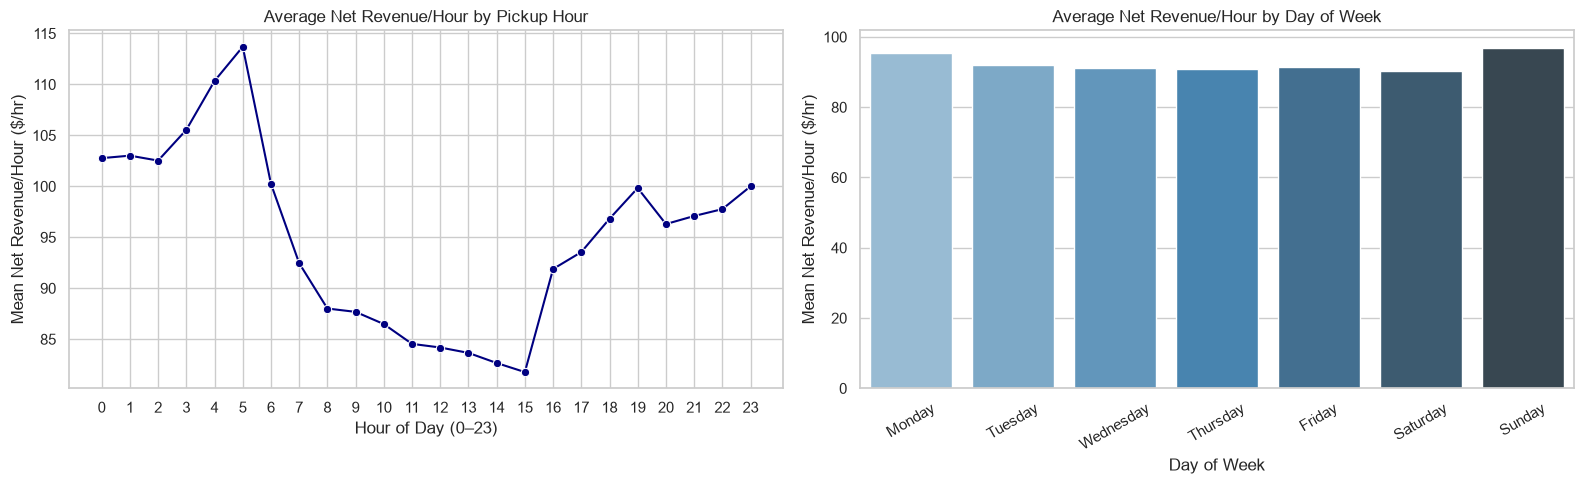

In [25]:
# Filter dataframe at the 99th percentile cap for clear trend visualization
viz_df = eda_df[eda_df['net_revenue_per_hour'] <= cap_value]

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# 1. Hourly Trends
hourly_agg = viz_df.groupby('pickup_hour')['net_revenue_per_hour'].mean().reset_index()
sns.lineplot(data=hourly_agg, x='pickup_hour', y='net_revenue_per_hour', marker='o', ax=axes[0], color='navy')
axes[0].set_title('Average Net Revenue/Hour by Pickup Hour')
axes[0].set_xlabel('Hour of Day (0–23)')
axes[0].set_ylabel('Mean Net Revenue/Hour ($/hr)')
axes[0].set_xticks(range(0, 24))

# 2. Day of Week Trends (Fixed Seaborn hue deprecation warning)
weekday_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
day_agg = viz_df.groupby('day_of_week')['net_revenue_per_hour'].mean().reindex(weekday_order).reset_index()
sns.barplot(
    data=day_agg, x='day_of_week', y='net_revenue_per_hour', 
    hue='day_of_week', palette='Blues_d', legend=False, ax=axes[1]
)
axes[1].set_title('Average Net Revenue/Hour by Day of Week')
axes[1].set_xlabel('Day of Week')
axes[1].set_ylabel('Mean Net Revenue/Hour ($/hr)')
axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

### 2.3 Spatial Analysis (Top 10 vs. Bottom 10 Pickup Zones) & Feature Correlations

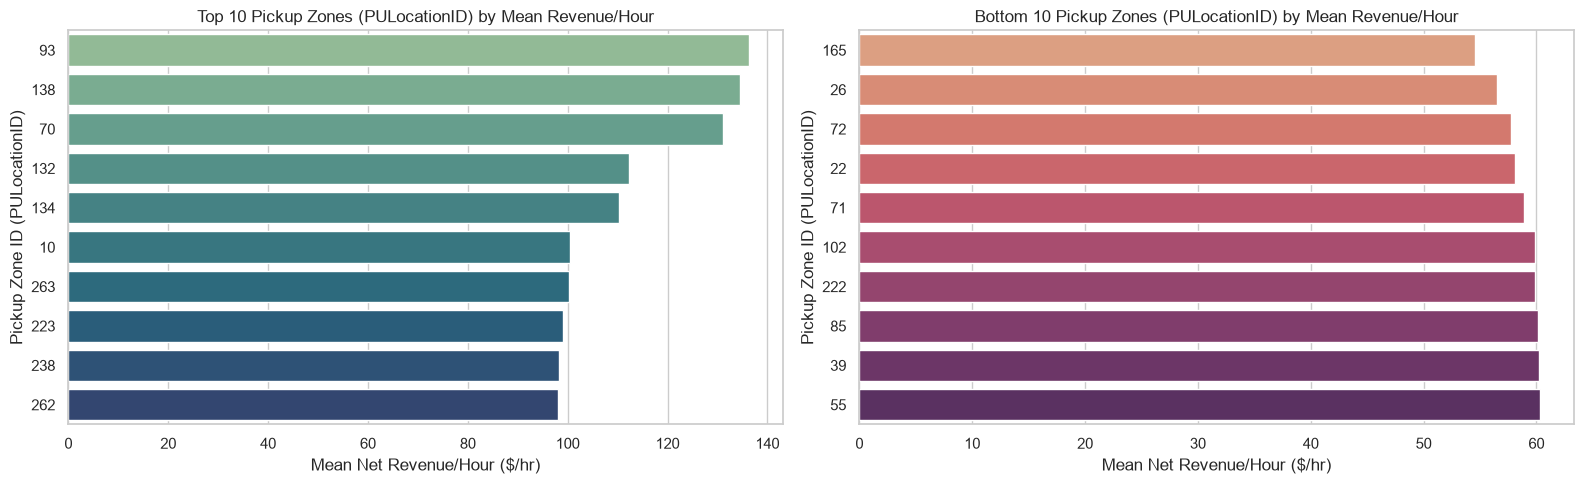

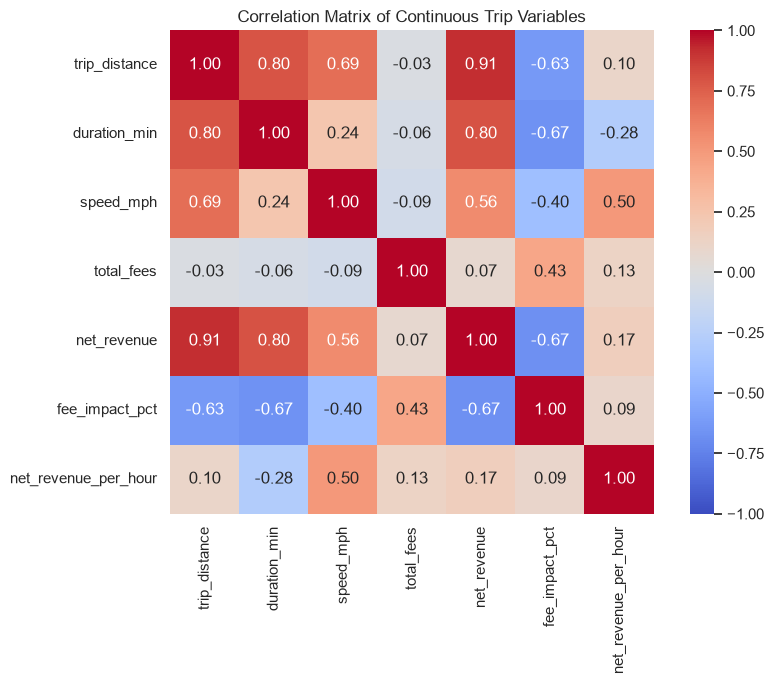

In [26]:
# Compute mean revenue and trip volume per pickup zone (PULocationID)
zone_stats = eda_df.groupby('PULocationID').agg(
    mean_revenue=('net_revenue_per_hour', 'mean'),
    trip_count=('net_revenue_per_hour', 'count')
).reset_index()

# Filter for zones with sufficient sample support (>= 50 trips in sample)
zone_stats_filtered = zone_stats[zone_stats['trip_count'] >= 50].copy()
zone_stats_filtered['PULocationID_str'] = zone_stats_filtered['PULocationID'].astype(str)

top_10 = zone_stats_filtered.nlargest(10, 'mean_revenue')
bottom_10 = zone_stats_filtered.nsmallest(10, 'mean_revenue')

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Top 10 Pickup Zones
sns.barplot(
    data=top_10, x='mean_revenue', y='PULocationID_str', 
    hue='PULocationID_str', palette='crest', legend=False, ax=axes[0]
)
axes[0].set_title('Top 10 Pickup Zones (PULocationID) by Mean Revenue/Hour')
axes[0].set_xlabel('Mean Net Revenue/Hour ($/hr)')
axes[0].set_ylabel('Pickup Zone ID (PULocationID)')

# Bottom 10 Pickup Zones
sns.barplot(
    data=bottom_10, x='mean_revenue', y='PULocationID_str', 
    hue='PULocationID_str', palette='flare', legend=False, ax=axes[1]
)
axes[1].set_title('Bottom 10 Pickup Zones (PULocationID) by Mean Revenue/Hour')
axes[1].set_xlabel('Mean Net Revenue/Hour ($/hr)')
axes[1].set_ylabel('Pickup Zone ID (PULocationID)')

plt.tight_layout()
plt.show()

# Correlation Matrix of Continuous Variables
num_cols = [
    'trip_distance', 'duration_min', 'speed_mph', 
    'total_fees', 'net_revenue', 'fee_impact_pct', 
    'net_revenue_per_hour'
]

corr_matrix = eda_df[num_cols].corr()

plt.figure(figsize=(9, 7))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', vmin=-1, vmax=1, square=True)
plt.title('Correlation Matrix of Continuous Trip Variables')
plt.tight_layout()
plt.show()

# 3. Data Cleaning & Outlier Filtering

In [27]:
initial_rows = len(df)

# 1. Remove negative fees, taxes, and fare adjustments
fee_cols = [
    'cbd_congestion_fee', 'congestion_surcharge', 'Airport_fee', 
    'mta_tax', 'extra', 'improvement_surcharge', 'tolls_amount', 
    'tip_amount', 'total_fees', 'fee_impact_pct'
]
df = df[(df[fee_cols] >= 0).all(axis=1)].copy()
after_fees = len(df)
print(f"Rows after removing negative fees/taxes: {after_fees:,} (Dropped {initial_rows - after_fees:,})")

# 2. Ensure strictly positive fare, duration, and net revenue amounts
df = df[(df['fare_amount'] > 0) & (df['total_amount'] > 0) & (df['net_revenue'] > 0) & (df['duration_min'] > 0)].copy()
after_revenue = len(df)
print(f"Rows after enforcing positive revenue:   {after_revenue:,} (Dropped {after_fees - after_revenue:,})")

# 3. Remove zero-passenger trips and invalid TLC RatecodeIDs (valid codes are 1 to 6)
df = df[(df['passenger_count'] > 0) & (df['RatecodeID'].between(1, 6))].copy()
after_validity = len(df)
print(f"Rows after removing invalid trips/codes: {after_validity:,} (Dropped {after_revenue - after_validity:,})")

# 4. Filter extreme target outliers (capping net_revenue_per_hour at $500/hr)
df = df[df['net_revenue_per_hour'] <= 500].copy()
final_rows = len(df)
print(f"Rows after capping target outliers:      {final_rows:,} (Dropped {after_validity - final_rows:,})")

print(f"\nTotal rows removed: {initial_rows - final_rows:,} ({((initial_rows - final_rows) / initial_rows) * 100:.2f}%)")

# Verification Summary
print("\n----- CLEANED DATA VERIFICATION -----")
print(f"Final Row Count:       {len(df):,}")
print(f"Total Missing Values:  {df.isnull().sum().sum()}")
print(f"Min Total Fees:        ${df['total_fees'].min():.2f}")
print(f"Min Fee Impact %:      {df['fee_impact_pct'].min():.2f}%")
print(f"Min Passenger Count:   {df['passenger_count'].min()}")
print(f"Max RatecodeID:        {df['RatecodeID'].max()}")
print(f"Min Speed (mph):       {df['speed_mph'].min():.2f}")
print(f"Max Net Revenue/Hour:  ${df['net_revenue_per_hour'].max():.2f}/hr")

# Save cleaned trip-level dataset
output_path = '../data/Final_NYC_Taxi_Cleaned.csv'
df.to_csv(output_path, index=False)
print(f"\nCleaned dataset saved to '{output_path}'.")

Rows after removing negative fees/taxes: 3,946,629 (Dropped 66)
Rows after enforcing positive revenue:   3,946,629 (Dropped 0)
Rows after removing invalid trips/codes: 3,857,230 (Dropped 89,399)
Rows after capping target outliers:      3,857,230 (Dropped 0)

Total rows removed: 89,465 (2.27%)

----- CLEANED DATA VERIFICATION -----
Final Row Count:       3,857,230
Total Missing Values:  0
Min Total Fees:        $0.00
Min Fee Impact %:      0.00%
Min Passenger Count:   1
Max RatecodeID:        6
Min Speed (mph):       1.00
Max Net Revenue/Hour:  $223.78/hr

Cleaned dataset saved to '../data/Final_NYC_Taxi_Cleaned.csv'.


# 4. Spatiotemporal Aggregation & Lag Feature Engineering

### 4.1 Aggregate Trips to Zone-Hour Level (`PULocationID` × `pickup_date`)

In [28]:
print("Loading cleaned data and aggregating to Zone-Hour level...")
df = pd.read_csv('../data/Final_NYC_Taxi_Cleaned.csv')
df['pickup_date'] = pd.to_datetime(df['tpep_pickup_datetime']).dt.floor('h')

# Aggregate metrics by Pickup Zone and Hour
grouped = df.groupby(['PULocationID', 'pickup_date']).agg(
    trip_count=('total_amount', 'count'),
    total_net_rev=('net_revenue', 'sum'),
    total_duration_min=('duration_min', 'sum'),
    avg_speed_mph=('speed_mph', 'mean'),
    avg_fee_impact_pct=('fee_impact_pct', 'mean')
).reset_index()

# Compute Zone-Hour Net Revenue per Hour ($/hr)
grouped = grouped[grouped['total_duration_min'] > 0].copy()
grouped['net_revenue_per_hour'] = (grouped['total_net_rev'] / grouped['total_duration_min']) * 60

# Enforce target bounds at the aggregated zone-hour level
grouped = grouped[(grouped['net_revenue_per_hour'] > 0) & (grouped['net_revenue_per_hour'] <= 500)].copy()
print(f"Aggregated Zone-Hour observations: {len(grouped):,}")
display(grouped.head())

Loading cleaned data and aggregating to Zone-Hour level...
Aggregated Zone-Hour observations: 546,778


,PULocationID,pickup_date,trip_count,total_net_rev,total_duration_min,avg_speed_mph,avg_fee_impact_pct,net_revenue_per_hour
0,1,2025-01-02 16:00:00,1,125.80,45.650000,21.279299,0.788644,165.345016
1,1,2025-01-26 23:00:00,1,122.46,34.650000,29.610390,1.408904,212.051948
2,1,2025-02-14 15:00:00,1,111.26,62.233333,13.979646,1.548536,107.267274
3,1,2025-02-24 16:00:00,1,125.85,46.816667,20.095408,1.371473,161.288715
5,1,2025-03-03 12:00:00,1,235.90,33.766667,56.150049,0.422119,419.170780


### 4.2 Full Cartesian Time Grid & Autoregressive Lag Features

In [29]:
print("Constructing full Cartesian time grid and enhanced lag features...")
unique_zones = grouped['PULocationID'].unique()
all_hours = pd.date_range(start=grouped['pickup_date'].min(), end=grouped['pickup_date'].max(), freq='h')

# Build complete grid so shift(1) and shift(24) represent exact 1-hour and 24-hour time steps
grid = pd.MultiIndex.from_product(
    [unique_zones, all_hours], 
    names=['PULocationID', 'pickup_date']
).to_frame().reset_index(drop=True)

abt = pd.merge(grid, grouped, on=['PULocationID', 'pickup_date'], how='left')
abt['trip_count'] = abt['trip_count'].fillna(0)
abt = abt.sort_values(['PULocationID', 'pickup_date']).reset_index(drop=True)

# 1. Create 1-hour and 24-hour lag features per zone
for col in ['trip_count', 'avg_speed_mph', 'avg_fee_impact_pct']:
    abt[f'{col}_lag1h'] = abt.groupby('PULocationID')[col].shift(1)
    abt[f'{col}_lag24h'] = abt.groupby('PULocationID')[col].shift(24)

# Forward-fill and back-fill continuous lags within each zone to handle zero-trip hours
lag_cont_cols = [
    'avg_speed_mph_lag1h', 'avg_speed_mph_lag24h', 
    'avg_fee_impact_pct_lag1h', 'avg_fee_impact_pct_lag24h'
]
for col in lag_cont_cols:
    abt[col] = abt.groupby('PULocationID')[col].ffill().bfill().fillna(0)

# 2. Add 3-Hour Rolling Historical Averages (smooths out 1-hour noise without leakage)
abt['speed_roll3h'] = abt.groupby('PULocationID')['avg_speed_mph_lag1h'].transform(
    lambda x: x.rolling(3, min_periods=1).mean()
)
abt['fee_roll3h'] = abt.groupby('PULocationID')['avg_fee_impact_pct_lag1h'].transform(
    lambda x: x.rolling(3, min_periods=1).mean()
)

# 3. Extract Calendar, Holiday, and Cyclical (sin/cos) Time Features
abt['pickup_hour'] = abt['pickup_date'].dt.hour
abt['hour_sin'] = np.sin(2 * np.pi * abt['pickup_hour'] / 24.0)
abt['hour_cos'] = np.cos(2 * np.pi * abt['pickup_hour'] / 24.0)

abt['day_of_week'] = abt['pickup_date'].dt.day_name()
abt['is_weekend'] = (abt['pickup_date'].dt.dayofweek >= 5).astype(int)

cal = USFederalHolidayCalendar()
holidays = cal.holidays(start=abt['pickup_date'].min(), end=abt['pickup_date'].max())
abt['is_holiday'] = abt['pickup_date'].dt.normalize().isin(holidays).astype(int)

# 4. Filter to commercially active zone-hours (trip_count >= 5) to remove single-trip noise
modeling_df = abt.dropna(subset=['net_revenue_per_hour', 'trip_count_lag24h']).copy()
modeling_df = modeling_df[modeling_df['trip_count'] >= 5].copy()

print(f"Total active zone-hour rows ready for modeling (trip_count >= 5): {len(modeling_df):,}")

Constructing full Cartesian time grid and enhanced lag features...
Total active zone-hour rows ready for modeling (trip_count >= 5): 226,956


# 5. Chronological Data Split & Dual Preprocessing Pipelines

In [35]:
print("Splitting dataset chronologically (70% Train / 15% Validation / 15% Test)...")
modeling_df = modeling_df.sort_values('pickup_date').reset_index(drop=True)

# Updated feature list including cyclical time, holidays, and 3h rolling lags
features = [
    'PULocationID', 'pickup_hour', 'hour_sin', 'hour_cos',
    'day_of_week', 'is_weekend', 'is_holiday',
    'trip_count_lag1h', 'trip_count_lag24h', 
    'avg_speed_mph_lag1h', 'avg_speed_mph_lag24h', 'speed_roll3h',
    'avg_fee_impact_pct_lag1h', 'avg_fee_impact_pct_lag24h', 'fee_roll3h'
]
target = 'net_revenue_per_hour'

n = len(modeling_df)
train_end = int(n * 0.70)
val_end = int(n * 0.85)

train = modeling_df.iloc[:train_end]
val = modeling_df.iloc[train_end:val_end]
test = modeling_df.iloc[val_end:]

X_train, y_train = train[features].copy(), train[target].copy()
X_val, y_val = val[features].copy(), val[target].copy()
X_test, y_test = test[features].copy(), test[target].copy()

print(f"Train set: {X_train.shape[0]:,} rows ({train['pickup_date'].min()} to {train['pickup_date'].max()})")
print(f"Val set:   {X_val.shape[0]:,} rows ({val['pickup_date'].min()} to {val['pickup_date'].max()})")
print(f"Test set:  {X_test.shape[0]:,} rows ({test['pickup_date'].min()} to {test['pickup_date'].max()})")

# ---------------------------------------------------------
# Pipeline A: Native Categorical Formatting for XGBoost
# ---------------------------------------------------------
X_train_xgb, X_val_xgb, X_test_xgb = X_train.copy(), X_val.copy(), X_test.copy()

loc_dtype = CategoricalDtype(categories=modeling_df['PULocationID'].unique(), ordered=False)
day_dtype = CategoricalDtype(categories=modeling_df['day_of_week'].unique(), ordered=False)

for df_split in [X_train_xgb, X_val_xgb, X_test_xgb]:
    df_split['PULocationID'] = df_split['PULocationID'].astype(loc_dtype)
    df_split['day_of_week'] = df_split['day_of_week'].astype(day_dtype)

# ---------------------------------------------------------
# Pipeline B: Scaled & One-Hot Encoded Matrix for SVR & Neural Net
# ---------------------------------------------------------
numeric_features = [
    'pickup_hour', 'hour_sin', 'hour_cos', 'is_weekend', 'is_holiday',
    'trip_count_lag1h', 'trip_count_lag24h', 
    'avg_speed_mph_lag1h', 'avg_speed_mph_lag24h', 'speed_roll3h',
    'avg_fee_impact_pct_lag1h', 'avg_fee_impact_pct_lag24h', 'fee_roll3h'
]
categorical_features = ['PULocationID', 'day_of_week']

numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical_features)
    ]
)

X_train_scaled = preprocessor.fit_transform(X_train)
X_val_scaled = preprocessor.transform(X_val)
X_test_scaled = preprocessor.transform(X_test)

model_results = {}

def evaluate_and_log(model_name, model, X_eval, y_eval, dataset_label="Test"):
    preds = model.predict(X_eval)
    mae = mean_absolute_error(y_eval, preds)
    rmse = np.sqrt(mean_squared_error(y_eval, preds))
    r2 = r2_score(y_eval, preds)
    
    print("==========================================")
    print(f" {model_name} — {dataset_label} Set Evaluation")
    print("==========================================")
    print(f"MAE:  USD {mae:.2f}/hr")
    print(f"RMSE: USD {rmse:.2f}/hr")
    print(f"R²:   {r2:.4f}\n")
    
    if dataset_label == "Test":
        model_results[model_name] = {'MAE (USD/hr)': mae, 'RMSE (USD/hr)': rmse, 'R² Score': r2}
    return preds

print("\nPreprocessing complete!")

Splitting dataset chronologically (70% Train / 15% Validation / 15% Test)...
Train set: 158,869 rows (2025-01-02 00:00:00 to 2025-08-24 17:00:00)
Val set:   34,043 rows (2025-08-24 17:00:00 to 2025-10-11 23:00:00)
Test set:  34,044 rows (2025-10-11 23:00:00 to 2025-11-30 23:00:00)

Preprocessing complete!


# 6. Model Training & Individual Evaluation

### 6.1 Model 1: XGBoost Regressor (Champion Model)

In [31]:
# Train and Evaluate XGBoost
print("Training XGBoost Regressor (Champion)...")

xgb_model = xgb.XGBRegressor(
    objective='reg:absoluteerror',
    n_estimators=500,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    enable_categorical=True,
    early_stopping_rounds=30,
    n_jobs=-1,
    random_state=42
)

xgb_model.fit(
    X_train_xgb, y_train, 
    eval_set=[(X_val_xgb, y_val)], 
    verbose=50
)

# Evaluate XGBoost on Validation and Test sets
_ = evaluate_and_log("XGBoost (Champion)", xgb_model, X_val_xgb, y_val, dataset_label="Validation")
xgb_preds = evaluate_and_log("XGBoost (Champion)", xgb_model, X_test_xgb, y_test, dataset_label="Test")

Training XGBoost Regressor (Champion)...
[0]	validation_0-mae:11.87487
[50]	validation_0-mae:8.18073
[100]	validation_0-mae:7.73433
[150]	validation_0-mae:7.62467
[200]	validation_0-mae:7.57235
[250]	validation_0-mae:7.54877
[300]	validation_0-mae:7.52865
[350]	validation_0-mae:7.52098
[400]	validation_0-mae:7.51518
[450]	validation_0-mae:7.51184
[499]	validation_0-mae:7.50764
 XGBoost (Champion) — Validation Set Evaluation
MAE:  USD 7.51/hr
RMSE: USD 10.39/hr
R²:   0.6020

 XGBoost (Champion) — Test Set Evaluation
MAE:  USD 9.39/hr
RMSE: USD 12.82/hr
R²:   0.5098



### 6.2 Model 2: Support Vector Regressor - SVR (Challenger 1)

In [32]:
# Train and Evaluate SVR (10% Stratified/Reproducible Subsample for O(N^2) scalability)
print("Training SVR Challenger 1 (10% Reproducible Subsample)...")

rng = np.random.default_rng(seed=42)
svr_sample_idx = rng.choice(X_train_scaled.shape[0], size=int(X_train_scaled.shape[0] * 0.10), replace=False)

X_train_svr = X_train_scaled[svr_sample_idx]
y_train_svr = y_train.iloc[svr_sample_idx]

svr_model = SVR(kernel='rbf', C=10.0, epsilon=0.1, gamma='scale', cache_size=1000)
svr_model.fit(X_train_svr, y_train_svr)

# Evaluate SVR on Validation and Test sets
_ = evaluate_and_log("SVR (Challenger 1)", svr_model, X_val_scaled, y_val, dataset_label="Validation")
svr_preds = evaluate_and_log("SVR (Challenger 1)", svr_model, X_test_scaled, y_test, dataset_label="Test")

Training SVR Challenger 1 (10% Reproducible Subsample)...
 SVR (Challenger 1) — Validation Set Evaluation
MAE:  USD 7.82/hr
RMSE: USD 10.90/hr
R²:   0.5617

 SVR (Challenger 1) — Test Set Evaluation
MAE:  USD 9.83/hr
RMSE: USD 13.53/hr
R²:   0.4546



### 6.3 Model 3: Multi-Layer Perceptron Neural Network (Challenger 2)

In [33]:
# Train and Evaluate Neural Network Independently (with Early Stopping enabled)
print("Training Neural Network Challenger 2 (MLPRegressor)...")

nn_model = MLPRegressor(
    hidden_layer_sizes=(64, 32),
    activation='relu',
    solver='adam',
    batch_size=256,
    learning_rate_init=0.001,
    max_iter=200,
    early_stopping=True,         # Prevents infinite hanging by monitoring internal validation loss
    validation_fraction=0.1,
    n_iter_no_change=10,
    random_state=42,
    verbose=True
)

nn_model.fit(X_train_scaled, y_train)

# Evaluate Neural Network on Validation and Test sets
_ = evaluate_and_log("Neural Network (Challenger 2)", nn_model, X_val_scaled, y_val, dataset_label="Validation")
nn_preds = evaluate_and_log("Neural Network (Challenger 2)", nn_model, X_test_scaled, y_test, dataset_label="Test")

Training Neural Network Challenger 2 (MLPRegressor)...
Iteration 1, loss = 865.78841364
Validation score: 0.496636
Iteration 2, loss = 70.87848046
Validation score: 0.551159
Iteration 3, loss = 66.57070856
Validation score: 0.565321
Iteration 4, loss = 64.92292495
Validation score: 0.573449
Iteration 5, loss = 63.83593699
Validation score: 0.579253
Iteration 6, loss = 62.95954668
Validation score: 0.585278
Iteration 7, loss = 62.23940733
Validation score: 0.589271
Iteration 8, loss = 61.65265642
Validation score: 0.589880
Iteration 9, loss = 61.12765794
Validation score: 0.594267
Iteration 10, loss = 60.70329252
Validation score: 0.597218
Iteration 11, loss = 60.35894650
Validation score: 0.598835
Iteration 12, loss = 59.99129504
Validation score: 0.597551
Iteration 13, loss = 59.68649024
Validation score: 0.603526
Iteration 14, loss = 59.39286842
Validation score: 0.602220
Iteration 15, loss = 59.15708960
Validation score: 0.603517
Iteration 16, loss = 58.91858865
Validation score: 0.

# 7. Final Side-by-Side Model Comparison

================ FINAL SIDE-BY-SIDE TEST SET COMPARISON ================


,Model,MAE (USD/hr),RMSE (USD/hr),R² Score
0,XGBoost (Champion),$9.39,$12.82,0.5098
1,SVR (Challenger 1),$9.83,$13.53,0.4546
2,Neural Network (Challenger 2),$10.03,$13.37,0.4670


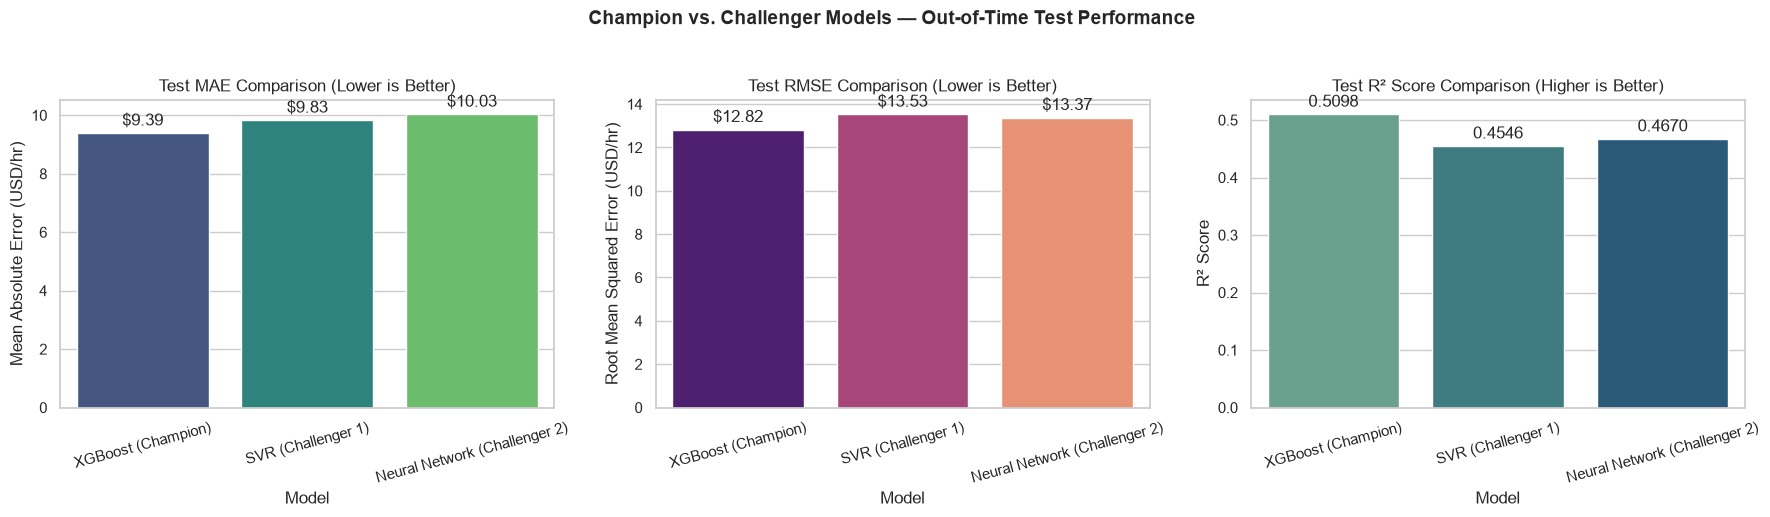

In [34]:
# Compile all logged test set metrics into a clean comparison table
comparison_df = pd.DataFrame(model_results).T.reset_index()

# Standardize column names by position
comparison_df.columns = ['Model', 'MAE (USD/hr)', 'RMSE (USD/hr)', 'R² Score']
comparison_df = comparison_df.sort_values(by='MAE (USD/hr)', ascending=True).reset_index(drop=True)
currency = chr(36)

# Create a formatted copy for clean table display
display_df = comparison_df.copy()
display_df['MAE (USD/hr)'] = display_df['MAE (USD/hr)'].apply(lambda x: f"{currency}{x:,.2f}")
display_df['RMSE (USD/hr)'] = display_df['RMSE (USD/hr)'].apply(lambda x: f"{currency}{x:,.2f}")
display_df['R² Score'] = display_df['R² Score'].apply(lambda x: f"{x:.4f}")

print("================ FINAL SIDE-BY-SIDE TEST SET COMPARISON ================")
display(display_df)

# Visual Side-by-Side Comparison Charts (uses numeric comparison_df)
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. MAE Comparison
sns.barplot(data=comparison_df, x='Model', y='MAE (USD/hr)', hue='Model', palette='viridis', legend=False, ax=axes[0])
axes[0].set_title('Test MAE Comparison (Lower is Better)')
axes[0].set_ylabel('Mean Absolute Error (USD/hr)')
axes[0].tick_params(axis='x', rotation=15)
for container in axes[0].containers:
    axes[0].bar_label(container, fmt=f'{currency}%.2f', padding=3)

# 2. RMSE Comparison
sns.barplot(data=comparison_df, x='Model', y='RMSE (USD/hr)', hue='Model', palette='magma', legend=False, ax=axes[1])
axes[1].set_title('Test RMSE Comparison (Lower is Better)')
axes[1].set_ylabel('Root Mean Squared Error (USD/hr)')
axes[1].tick_params(axis='x', rotation=15)
for container in axes[1].containers:
    axes[1].bar_label(container, fmt=f'{currency}%.2f', padding=3)

# 3. R² Score Comparison
sns.barplot(data=comparison_df, x='Model', y='R² Score', hue='Model', palette='crest', legend=False, ax=axes[2])
axes[2].set_title('Test R² Score Comparison (Higher is Better)')
axes[2].set_ylabel('R² Score')
axes[2].tick_params(axis='x', rotation=15)
for container in axes[2].containers:
    axes[2].bar_label(container, fmt='%.4f', padding=3)

plt.suptitle('Champion vs. Challenger Models — Out-of-Time Test Performance', fontsize=14, fontweight='bold', y=1.03)
plt.tight_layout()
plt.show()